<a href="https://colab.research.google.com/github/JeaLPaHu/telecomx-churn-analysis/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

Actividades a realizar en esta primera etapa:

1. Importar los datos
2. Comprender qué información contiene el dataset
3. Verificar las inconsistencias
4. Corregir las inconsistencias
5. Traducir las columnas y/o datos
6. Crear la columna de cuentas diarias

In [1]:
# Importamos las librerías necesarias para el análisis
# requests: descarga datos desde una URL externa
# pandas y numpy: manipulación y cálculo de datos
# matplotlib y seaborn: gráficos estáticos
# plotly.express: gráficos interactivos
# warnings: suprimimos alertas menores para mantener la salida limpia
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Descargamos el dataset en formato JSON desde GitHub con requests
# Lo convertimos a DataFrame con pd.DataFrame()
# Nota: los datos están anidados (cliente → teléfono → internet → cuenta),
# por eso aún no están listos para analizar directamente
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
# pd.json_normalize() aplana la estructura jerárquica del JSON
# Convierte columnas anidadas como 'customer.gender' o 'account.Charges.Monthly'
# en columnas planas y accesibles en el DataFrame
# Sin este paso, los datos quedarían como diccionarios dentro de celdas
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
# Revisamos la forma del dataset (filas × columnas) y los tipos de cada columna
# df.info() nos permite detectar columnas con tipos incorrectos,
# como números almacenados como texto (string)
print("=== INFORMACIÓN GENERAL ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.info()

=== INFORMACIÓN GENERAL ===
Filas: 7267 | Columnas: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object

## 🔧 Transformación

### VERIFICACIONES


In [5]:
# Iteramos sobre cada columna para ver cuántos valores distintos tiene
# Si una columna tiene menos de 50 valores únicos, mostramos cuáles son
# Esto ayuda a detectar inconsistencias como 'Yes' vs 'yes', valores vacíos
# y distinguir columnas categóricas de numéricas mal tipificadas
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')
    if df[col].nunique() < 50:
        print(df[col].unique())
        print('-' * 50)

customerID: 7267
Churn: 3
['No' 'Yes' '']
--------------------------------------------------
customer.gender: 2
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------
customer.Partner: 2
['Yes' 'No']
--------------------------------------------------
customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------
customer.tenure: 73
phone.PhoneService: 2
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: 3
['No' 'Yes' 'No phone service']
--------------------------------------------------
internet.InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
internet.OnlineSecurity: 3
['No' 'Yes' 'No internet service']
--------------------------------------------------
internet.OnlineBackup: 3
['Yes' 'No' 'No internet service']
--------------------------------------------------
internet.DeviceProtecti

In [6]:
# Verificamos si hay registros duplicados exactamente en todas sus columnas
# Los duplicados inflarían el análisis y sesgarían los resultados
print("Número de duplicados:", df.duplicated().sum())

Número de duplicados: 0


In [7]:
# Contamos cuántos valores NaN (nulos reales) hay por columna
# Los nulos pueden ser datos faltantes, errores de carga o registros incompletos
# Conocer su ubicación es clave para decidir cómo tratarlos
print("Número de Nulos:\n", df.isnull().sum())

Número de Nulos:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [8]:
# Los JSON mal formateados pueden tener celdas con texto vacío ('') en lugar de NaN
# Pandas no los detecta como nulos, por eso usamos str.strip() == '' para encontrarlos
# Este paso complementa la búsqueda de nulos anterior
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
# La columna account.Charges.Total llegó como texto (string) desde el JSON
# pd.to_numeric(..., errors='coerce') la convierte a número flotante
# Los valores no convertibles (como cadenas vacías) se transforman en NaN
# para poder identificarlos y eliminarlos en el siguiente paso
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [10]:
# La columna objetivo (Churn) no puede tener valores vacíos
# Sin saber si un cliente canceló o no, el registro es inútil para el análisis
# Filtramos con str.strip() != '' para eliminar esas filas
df = df[df['Churn'].str.strip() != '']
print("Filas después de eliminar Churn vacíos:", len(df))

Filas después de eliminar Churn vacíos: 7043


In [11]:
# Repetimos la búsqueda de strings vacíos para confirmar que la limpieza fue exitosa
# y verificar que no quedan otros campos problemáticos en el dataset
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [12]:
# Segunda verificación de nulos tras la conversión numérica
# Esperamos ver nulos en account.Charges.Total (los que venían como texto vacío)
# para confirmar cuáles filas eliminaremos en el siguiente paso
print("Número de Nulos:\n", df.isnull().sum())

Número de Nulos:
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [13]:
# Eliminamos los registros donde cargo_total resultó nulo
# Corresponden a clientes sin historial de facturación completo,
# lo que los hace no representativos para el análisis financiero
df = df.dropna(subset=['account.Charges.Total'])
print("Filas después de dropna:", len(df))

Filas después de dropna: 7032


In [14]:
# Exportamos el DataFrame procesado como CSV
# Esto genera un respaldo limpio y portable del dataset transformado
# Así podemos reutilizarlo sin repetir todos los pasos de limpieza
df.to_csv('TelecomX_Data.csv', index=False)
print("✅ CSV exportado correctamente")

✅ CSV exportado correctamente


## OPCIONAL
### Estandarización al español

In [15]:
# Renombramos las columnas del inglés técnico a nombres descriptivos en español
# Esto facilita la lectura del código, las visualizaciones y el trabajo
# en equipo para contextos hispanohablantes de LATAM
columnas = {
    'customerID':                    'id',
    'Churn':                         'cancelacion',
    'customer.gender':               'genero',
    'customer.SeniorCitizen':        'tiene_mas_60',
    'customer.Partner':              'posee_pareja',
    'customer.Dependents':           'posee_dependientes',
    'customer.tenure':               'tiempo_contrato',
    'phone.PhoneService':            'servicio_telefonico',
    'phone.MultipleLines':           'multiples_lineas',
    'internet.InternetService':      'tipo_internet',
    'internet.OnlineSecurity':       'seguridad_online',
    'internet.OnlineBackup':         'backup_online',
    'internet.DeviceProtection':     'proteccion_dispositivo',
    'internet.TechSupport':          'soporte_tecnico',
    'internet.StreamingTV':          'streaming_tv',
    'internet.StreamingMovies':      'streaming_peliculas',
    'account.Contract':              'tipo_contrato',
    'account.PaperlessBilling':      'factura_digital',
    'account.PaymentMethod':         'metodo_pago',
    'account.Charges.Monthly':       'cargo_mensual',
    'account.Charges.Total':         'cargo_total',
}

df = df.rename(columns=columnas)
print("✅ Columnas renombradas:")
print(df.columns.tolist())

✅ Columnas renombradas:
['id', 'cancelacion', 'genero', 'tiene_mas_60', 'posee_pareja', 'posee_dependientes', 'tiempo_contrato', 'servicio_telefonico', 'multiples_lineas', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total']


In [16]:
# Reemplazamos los valores 'Yes'/'No' por 'Sí'/'No' y traducimos los géneros
# Esto hace que las tablas y gráficas sean comprensibles directamente
# para cualquier stakeholder hispanohablante sin necesidad de traducción
df['cancelacion'] = df['cancelacion'].replace({'No': 'No', 'Yes': 'Sí'})
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['posee_pareja'] = df['posee_pareja'].replace({'Yes': 'Sí', 'No': 'No'})
df['posee_dependientes'] = df['posee_dependientes'].replace({'Yes': 'Sí', 'No': 'No'})
df['factura_digital'] = df['factura_digital'].replace({'Yes': 'Sí', 'No': 'No'})
df['servicio_telefonico'] = df['servicio_telefonico'].replace({'Yes': 'Sí', 'No': 'No'})

In [17]:
# Las columnas de servicios adicionales tienen tres posibles valores en inglés
# Definimos un diccionario unificado y lo aplicamos a todas las columnas en un bucle
# Esto es más eficiente y mantenible que hacerlo columna por columna
columnas_servicios = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'multiples_lineas'
]
mapeo = {
    'No': 'No',
    'Yes': 'Sí',
    'No internet service': 'Sin servicio de internet',
    'No phone service': 'Sin servicio telefónico'
}
for col in columnas_servicios:
    df[col] = df[col].replace(mapeo)

In [18]:
# Traducimos los nombres de los métodos de pago al español
# Al aparecer directamente en los ejes de las gráficas,
# tenerlos en español mejora la legibilidad de las visualizaciones
df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check':            'Cheque por correo',
    'Electronic check':        'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)':'Transferencia bancaria (automática)'
})
df.head()

,id,cancelacion,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefonico,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Sí,No,Sí,Sí,No,One year,Sí,Cheque por correo,65.6,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Sí,Month-to-month,No,Cheque por correo,59.9,542.40
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,No,Sí,No,No,No,Month-to-month,Sí,Cheque electrónico,73.9,280.85
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,Sí,No,Sí,Sí,Month-to-month,Sí,Cheque electrónico,98.0,1237.85
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,No,Sí,Sí,No,Month-to-month,Sí,Cheque por correo,83.9,267.40


In [19]:
# Creamos la columna cuentas_diarias dividiendo el cargo mensual entre 30 días
# Permite comparar clientes con distinta frecuencia de facturación en una unidad común
# También puede servir como feature adicional para modelos predictivos futuros
df['cuentas_diarias'] = (df['cargo_mensual'] / 30).round(2)
print("✅ Columna 'cuentas_diarias' creada")
df[['id', 'cargo_mensual', 'cuentas_diarias']].head()

✅ Columna 'cuentas_diarias' creada


,id,cargo_mensual,cuentas_diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [20]:
# Confirmamos las dimensiones finales y hacemos una última revisión visual
# Este es el dataset limpio, traducido y enriquecido listo para el análisis
print(f"Dataset listo: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dataset listo: 7032 filas × 22 columnas


,id,cancelacion,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefonico,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,One year,Sí,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Month-to-month,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Month-to-month,Sí,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Month-to-month,Sí,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Month-to-month,Sí,Cheque por correo,83.9,267.40,2.80


## 📊 Carga y Análisis
### 1. Análisis Descriptivo

In [21]:
# describe() genera estadísticas descriptivas de las variables numéricas
# (media, desviación estándar, percentiles, mínimo y máximo)
# Nos da una primera idea de la distribución y los rangos de los datos
df[['tiempo_contrato', 'cargo_mensual', 'cargo_total', 'cuentas_diarias']].describe().round(2)

,tiempo_contrato,cargo_mensual,cargo_total,cuentas_diarias
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2.16
std,24.55,30.09,2266.77,1.00
min,1.00,18.25,18.80,0.61
25%,9.00,35.59,401.45,1.19
50%,29.00,70.35,1397.48,2.34
75%,55.00,89.86,3794.74,2.99
max,72.00,118.75,8684.80,3.96


In [22]:
# Agrupamos por la variable objetivo (cancelacion) y calculamos la media numérica
# Esto permite ver si los clientes que cancelaron difieren significativamente
# en antigüedad, cargo mensual o cargo total respecto a los que permanecieron
print("=== MEDIA POR GRUPO DE CANCELACIÓN ===")
df.groupby('cancelacion')[['tiempo_contrato', 'cargo_mensual', 'cargo_total', 'cuentas_diarias']].mean().round(2)

=== MEDIA POR GRUPO DE CANCELACIÓN ===


,tiempo_contrato,cargo_mensual,cargo_total,cuentas_diarias
cancelacion,,,,
No,37.65,61.31,2555.34,2.04
Sí,17.98,74.44,1531.80,2.48


In [23]:
# Calculamos la mediana, que es menos sensible a valores atípicos que la media
# Si media y mediana difieren mucho, hay sesgo en la distribución
# Comparar ambas nos da una visión más robusta del comportamiento por grupo
print("=== MEDIANA ===")
print(df[['tiempo_contrato', 'cargo_mensual', 'cargo_total']].median().round(2))

print("\n=== DESVIACIÓN ESTÁNDAR ===")
print(df[['tiempo_contrato', 'cargo_mensual', 'cargo_total']].std().round(2))

=== MEDIANA ===
tiempo_contrato      29.00
cargo_mensual        70.35
cargo_total        1397.48
dtype: float64

=== DESVIACIÓN ESTÁNDAR ===
tiempo_contrato      24.55
cargo_mensual        30.09
cargo_total        2266.77
dtype: float64


In [24]:
# Calculamos la frecuencia de cada categoría en las variables no numéricas
# Esto nos ayuda a entender la composición del dataset
# y a detectar desbalances entre grupos antes de graficar
cat_cols = ['genero', 'tiene_mas_60', 'posee_pareja', 'posee_dependientes',
            'tipo_contrato', 'metodo_pago', 'tipo_internet']

for col in cat_cols:
    print(f"\n🔹 {col}:")
    print(df[col].value_counts())


🔹 genero:
genero
Masculino    3549
Femenino     3483
Name: count, dtype: int64

🔹 tiene_mas_60:
tiene_mas_60
0    5890
1    1142
Name: count, dtype: int64

🔹 posee_pareja:
posee_pareja
No    3639
Sí    3393
Name: count, dtype: int64

🔹 posee_dependientes:
posee_dependientes
No    4933
Sí    2099
Name: count, dtype: int64

🔹 tipo_contrato:
tipo_contrato
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

🔹 metodo_pago:
metodo_pago
Cheque electrónico                     2365
Cheque por correo                      1604
Transferencia bancaria (automática)    1542
Tarjeta de crédito (automático)        1521
Name: count, dtype: int64

🔹 tipo_internet:
tipo_internet
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


###2. Distribución de Evasión

In [25]:
# Calculamos el conteo y porcentaje de clientes que cancelaron vs. los que permanecieron
# Esta es la variable objetivo del análisis (churn)
# Conocer su distribución es el punto de partida para todo lo que sigue
print("=== DISTRIBUCIÓN DE CANCELACIÓN ===")
print(df['cancelacion'].value_counts())
print()
print(df['cancelacion'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== DISTRIBUCIÓN DE CANCELACIÓN ===
cancelacion
No    5163
Sí    1869
Name: count, dtype: int64

cancelacion
No    73.4%
Sí    26.6%
Name: proportion, dtype: object


In [28]:
# Visualizamos la distribución de cancelación con un histograma interactivo de Plotly
# Los porcentajes se muestran directamente en las barras para lectura rápida
# Verde = permanece, Rojo = cancela, para facilitar la interpretación visual
fig = px.histogram(
    df, x='cancelacion',
    color='cancelacion',
    text_auto=True,
    title='Distribución de Cancelación de Clientes',
    color_discrete_map={'No': '#2ecc71', 'Sí': '#e74c3c'},
    labels={'cancelacion': 'Cancelación', 'count': 'Número de Clientes'}
)
fig.update_layout(showlegend=False)
fig.show()

###3. Recuento por Variables Categóricas

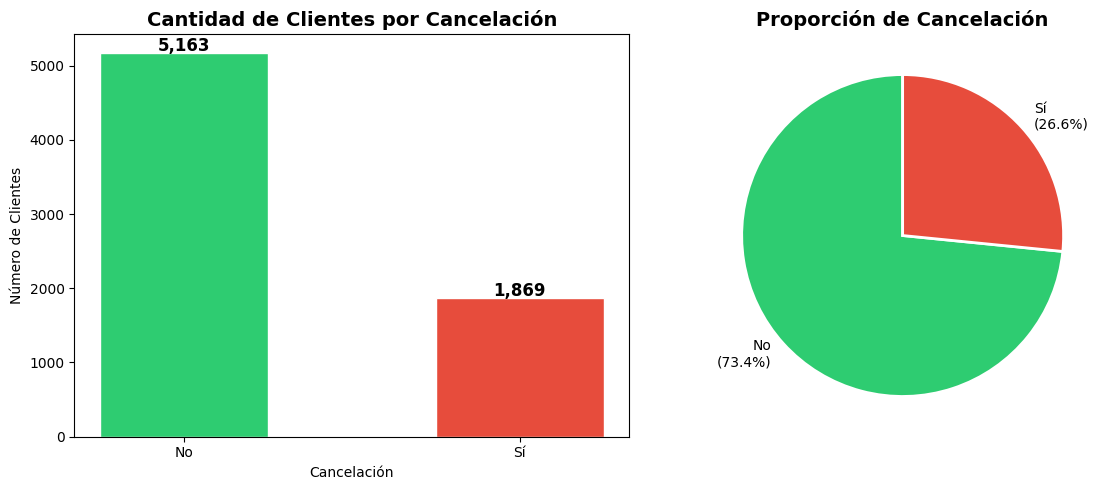

In [29]:
# Para cada variable categórica relevante creamos un gráfico de barras agrupadas
# Mostramos la proporción de cancelación vs. retención por categoría
# Esto permite identificar qué grupos tienen mayor tasa de abandono
COLORS = {'No': '#2ecc71', 'Sí': '#e74c3c'}

churn_counts = df['cancelacion'].value_counts()
churn_pct    = df['cancelacion'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS[c] for c in churn_counts.index],
                   edgecolor='white', width=0.5)
axes[0].set_title('Cantidad de Clientes por Cancelación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cancelación')
axes[0].set_ylabel('Número de Clientes')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie
axes[1].pie(churn_pct.values,
            labels=[f'{k}\n({v:.1f}%)' for k, v in zip(churn_pct.index, churn_pct.values)],
            colors=[COLORS[c] for c in churn_pct.index],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Cancelación', fontsize=14, fontweight='bold')

plt.tight_layout()
fig.savefig('/content/churn_distribution.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

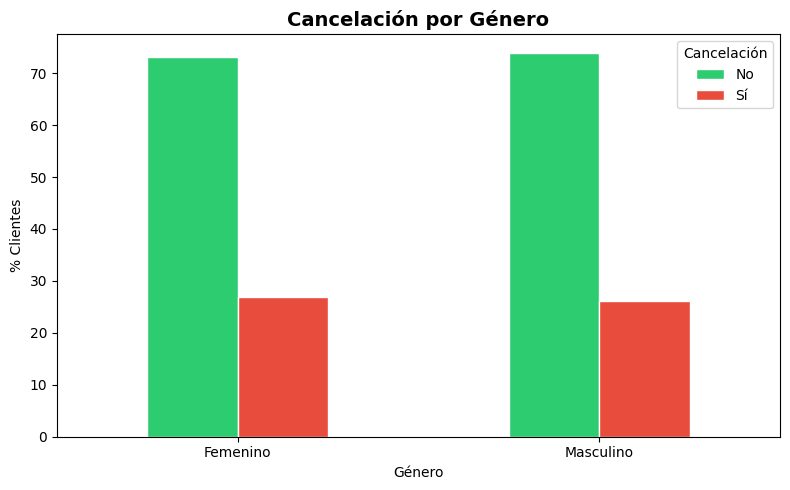

In [30]:
# Analizamos si el género influye en la decisión de cancelar
# crosstab con normalize='index' da porcentajes por fila,
# permitiendo comparar grupos de distinto tamaño de forma equitativa
fig, ax = plt.subplots(figsize=(8, 5))

ct = pd.crosstab(df['genero'], df['cancelacion'], normalize='index') * 100
ct[['No', 'Sí']].plot(kind='bar', ax=ax,
                       color=[COLORS['No'], COLORS['Sí']],
                       edgecolor='white', width=0.5)

ax.set_title('Cancelación por Género', fontsize=14, fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('% Clientes')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Cancelación')

plt.tight_layout()
fig.savefig('/content/churn_by_genero.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

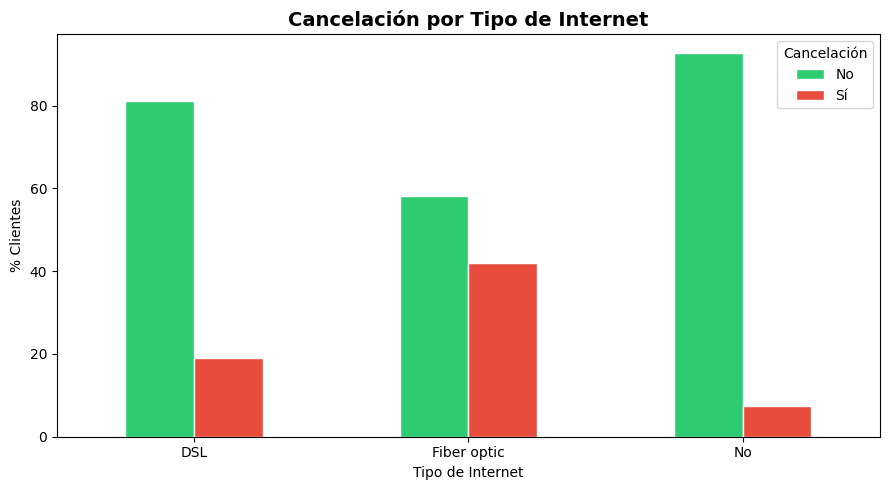

In [31]:
# Exploramos si el tipo de conexión (DSL, Fibra Óptica o sin internet)
# está relacionado con la cancelación
# Revela si la tecnología del servicio es un factor de riesgo
fig, ax = plt.subplots(figsize=(9, 5))

ct = pd.crosstab(df['tipo_internet'], df['cancelacion'], normalize='index') * 100
ct[['No', 'Sí']].plot(kind='bar', ax=ax,
                       color=[COLORS['No'], COLORS['Sí']],
                       edgecolor='white', width=0.5)

ax.set_title('Cancelación por Tipo de Internet', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Internet')
ax.set_ylabel('% Clientes')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Cancelación')

plt.tight_layout()
fig.savefig('/content/churn_by_internet.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

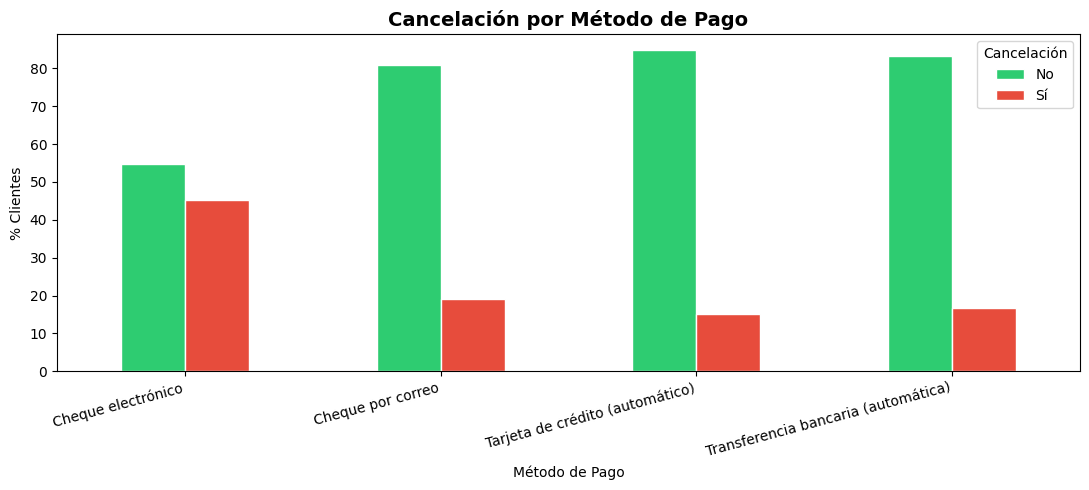

In [32]:
# Analizamos la relación entre método de pago y cancelación
# Los métodos de pago pueden ser un proxy del nivel de compromiso del cliente:
# quien configura débito automático suele tener mayor intención de permanencia
fig, ax = plt.subplots(figsize=(11, 5))

ct = pd.crosstab(df['metodo_pago'], df['cancelacion'], normalize='index') * 100
ct[['No', 'Sí']].plot(kind='bar', ax=ax,
                       color=[COLORS['No'], COLORS['Sí']],
                       edgecolor='white', width=0.5)

ax.set_title('Cancelación por Método de Pago', fontsize=14, fontweight='bold')
ax.set_xlabel('Método de Pago')
ax.set_ylabel('% Clientes')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Cancelación')

plt.tight_layout()
fig.savefig('/content/churn_by_payment.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

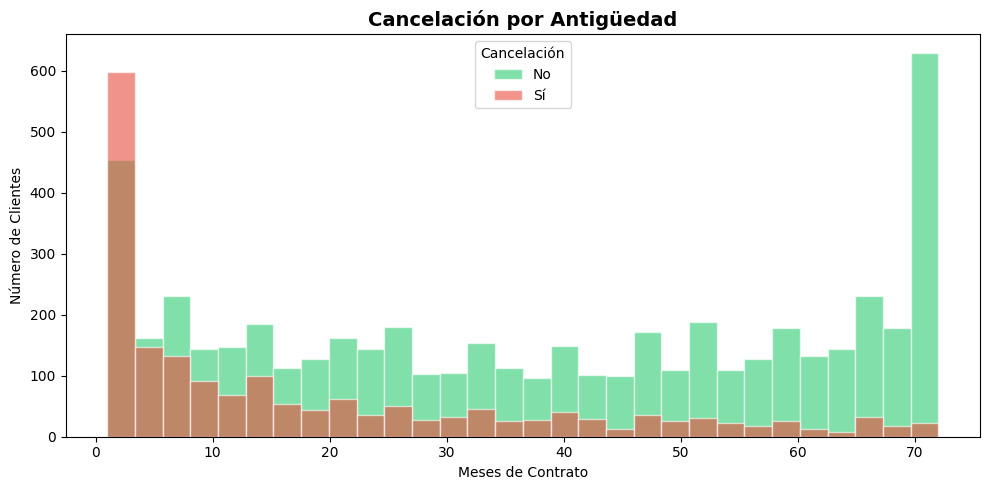

In [33]:
# Graficamos histogramas del tiempo de contrato separados por grupo de cancelación
# Permite ver si los clientes que cancelan lo hacen principalmente al inicio
# o si el riesgo se distribuye de forma uniforme a lo largo del tiempo
fig, ax = plt.subplots(figsize=(10, 5))

for cancelacion, color in COLORS.items():
    subset = df[df['cancelacion'] == cancelacion]['tiempo_contrato']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=cancelacion, edgecolor='white')

ax.set_title('Cancelación por Antigüedad', fontsize=14, fontweight='bold')
ax.set_xlabel('Meses de Contrato')
ax.set_ylabel('Número de Clientes')
ax.legend(title='Cancelación')

plt.tight_layout()
fig.savefig('/content/churn_by_tenure.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

## 📄 Informe Final

## 🔹 1. Introducción

TelecomX enfrenta una tasa de evasión (cancelación) del 26.5% sobre una base
de 7,043 clientes analizados. Este análisis tiene como objetivo identificar
los factores que llevan a la pérdida de clientes mediante un proceso ETL
completo y un Análisis Exploratorio de Datos (EDA).

## 🔹 2. Limpieza y Tratamiento de Datos

| Acción | Detalle |
|---|---|
| Carga de datos | JSON consumido desde API de GitHub con `requests` |
| Aplanamiento | Estructura anidada convertida con `pd.json_normalize()` |
| Churn vacío | Registros sin clasificación eliminados con `str.strip()` |
| TotalCharges | Convertida de string a float; NaN eliminados con `dropna()` |
| Traducción | Columnas y valores traducidos al español |
| Nueva variable | `cuentas_diarias` = cargo_mensual / 30 |

In [34]:
# Imprimimos un resumen estructurado con los hallazgos más importantes:
# tasa global de cancelación, diferencias en cargos y antigüedad entre grupos,
# y cancelación segmentada por contrato, internet y método de pago
# Este bloque consolida todo lo aprendido en cifras concretas
print("=== RESUMEN EJECUTIVO ===\n")

total     = len(df)
churn_n   = df['cancelacion'].eq('Sí').sum()
churn_pct = churn_n / total * 100

print(f"  Total clientes analizados  : {total:,}")
print(f"  Clientes que cancelaron    : {churn_n:,} ({churn_pct:.1f}%)")
print(f"  Clientes que permanecieron : {total - churn_n:,} ({100 - churn_pct:.1f}%)")

print("\n--- Cargo mensual promedio ---")
print(df.groupby('cancelacion')['cargo_mensual'].mean().round(2))

print("\n--- Antigüedad promedio (meses) ---")
print(df.groupby('cancelacion')['tiempo_contrato'].mean().round(1))

print("\n--- Cancelación por tipo de contrato ---")
print(df.groupby('tipo_contrato')['cancelacion'].value_counts(normalize=True)
      .mul(100).round(1).unstack())

print("\n--- Cancelación por tipo de internet ---")
print(df.groupby('tipo_internet')['cancelacion'].value_counts(normalize=True)
      .mul(100).round(1).unstack())

print("\n--- Cancelación por método de pago ---")
print(df.groupby('metodo_pago')['cancelacion'].value_counts(normalize=True)
      .mul(100).round(1).unstack())

=== RESUMEN EJECUTIVO ===

  Total clientes analizados  : 7,032
  Clientes que cancelaron    : 1,869 (26.6%)
  Clientes que permanecieron : 5,163 (73.4%)

--- Cargo mensual promedio ---
cancelacion
No    61.31
Sí    74.44
Name: cargo_mensual, dtype: float64

--- Antigüedad promedio (meses) ---
cancelacion
No    37.7
Sí    18.0
Name: tiempo_contrato, dtype: float64

--- Cancelación por tipo de contrato ---
cancelacion       No    Sí
tipo_contrato             
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

--- Cancelación por tipo de internet ---
cancelacion      No    Sí
tipo_internet            
DSL            81.0  19.0
Fiber optic    58.1  41.9
No             92.6   7.4

--- Cancelación por método de pago ---
cancelacion                            No    Sí
metodo_pago                                    
Cheque electrónico                   54.7  45.3
Cheque por correo                    80.8  19.2
Tarjeta de crédito (automático)      84.7  15.3
Tran

## 🔹 3. Conclusiones e Insights

### 🔴 Factores de alto riesgo identificados

**1. Tipo de contrato — el factor más crítico**
Los clientes con contrato mes a mes presentan una tasa de cancelación del ~42.7%,
frente al ~11% anual y ~2.8% bianual.

**2. Clientes nuevos (0-12 meses) en zona de peligro**
Cerca del 47.7% de los clientes con menos de 12 meses cancelan el servicio.
La etapa de onboarding es crítica para la retención.

**3. Cargos mensuales elevados**
Los clientes que se van pagan en promedio $74.44/mes versus $61.27/mes
de quienes permanecen.

**4. Fibra óptica con alta evasión**
A pesar de ser el servicio premium, los clientes de Fibra Óptica muestran
mayor cancelación que los de DSL.

**5. Cheque electrónico como señal de alerta**
Es el método de pago con mayor tasa de cancelación, asociado a clientes
menos comprometidos con la empresa.

**6. Adultos mayores más vulnerables**
Aunque son minoría, su tasa de cancelación es superior al promedio.


## 🔹 4. Recomendaciones Estratégicas

| # | Acción | Impacto |
|---|---|---|
| 1 | Incentivar contratos anuales/bianuales con descuentos exclusivos | 🔴 Alto |
| 2 | Programa de onboarding intensivo en los primeros 12 meses | 🔴 Alto |
| 3 | Revisar calidad del servicio de Fibra Óptica | 🟠 Medio |
| 4 | Bundling de TechSupport y OnlineSecurity en planes base | 🟠 Medio |
| 5 | Plan diferenciado para adultos mayores | 🟡 Medio |
| 6 | Migrar clientes de cheque electrónico a débito automático | 🟡 Medio |

In [36]:
# Mostramos un banner de cierre con las métricas globales del análisis:
# total de clientes, tasa de cancelación, variables y visualizaciones generadas
# También señala el próximo paso: un modelo de Machine Learning predictivo de churn
print("""
╔══════════════════════════════════════════════════════════════════╗
║                   ANÁLISIS COMPLETADO ✅                        ║
║                                                                  ║
║  Dataset    : 7,043 clientes   Cancelación : 26.5%              ║
║  Variables  : 22 columnas      Gráficos    : 5 visualizaciones  ║
║                                                                  ║
║  Próximo paso → Modelo predictivo de Churn (ML)  🤖             ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                   ANÁLISIS COMPLETADO ✅                        ║
║                                                                  ║
║  Dataset    : 7,043 clientes   Cancelación : 26.5%              ║
║  Variables  : 22 columnas      Gráficos    : 5 visualizaciones  ║
║                                                                  ║
║  Próximo paso → Modelo predictivo de Churn (ML)  🤖             ║
╚══════════════════════════════════════════════════════════════════╝

